# SILVA Optical Flow: RAFT and DEQ-Flow Bridge

RAFT introduced all-pairs correlation and recurrent flow refinement. DEQ-Flow
casts optical flow as a fixed-point solve. The SILVA package version is compact
and designed for tutorials and compact validation runs:

$$
u^\star=T_\theta(u^\star,I_1,I_2).
$$

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[22]](https://jseluis.github.io/silva-networks/paper/references/#ref-22), [[23]](https://jseluis.github.io/silva-networks/paper/references/#ref-23), [[24]](https://jseluis.github.io/silva-networks/paper/references/#ref-24). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import resolve_device, SolverConfig

torch.manual_seed(11)
np.random.seed(11)
device = resolve_device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Synthetic Translation Pair

The package generator creates two images and a known forward flow
$u=(u_x,u_y)$. This keeps the notebook small enough for CPU and Colab.

In [3]:
from silva_networks import make_silva_translation_flow_batch

batch = make_silva_translation_flow_batch(
    batch_size=1,
    channels=1,
    height=12,
    width=12,
    shift=(0.75, 0.25),
    device=device,
)
batch.image1.shape, batch.image2.shape, batch.flow[:, :, 0, 0]

(torch.Size([1, 1, 12, 12]),
 torch.Size([1, 1, 12, 12]),
 tensor([[0.7500, 0.2500]]))

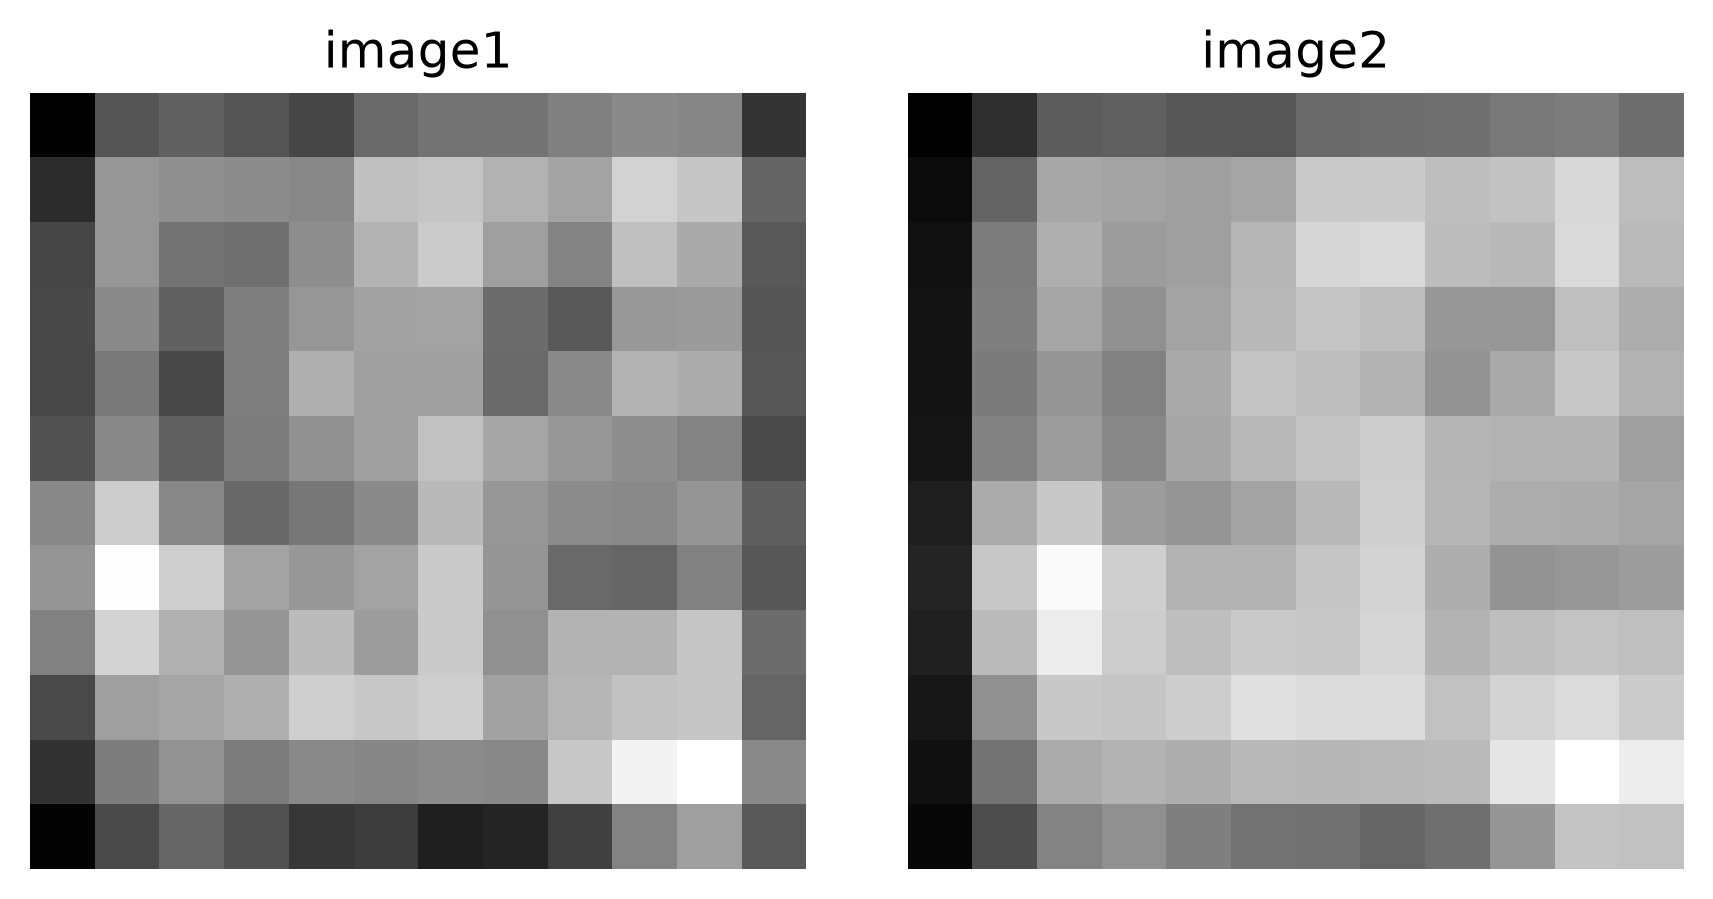

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(batch.image1[0, 0].detach().cpu(), cmap="gray")
axes[0].set_title("image1")
axes[1].imshow(batch.image2[0, 0].detach().cpu(), cmap="gray")
axes[1].set_title("image2")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

## Correlation and Local Lookup

Given feature maps $F_1,F_2$,

$$
C_{i,j,k,\ell}
=
\frac{\langle F_{1,:,i,j},F_{2,:,k,\ell}\rangle}{\sqrt C}.
$$

In [5]:
from silva_networks import (
    SILVAFlowFeatureEncoder,
    silva_all_pairs_correlation,
    silva_local_correlation_lookup,
)

encoder = SILVAFlowFeatureEncoder(in_channels=1, feature_dim=4).to(device)
f1 = encoder(batch.image1)
f2 = encoder(batch.image2)
corr = silva_all_pairs_correlation(f1, f2)
local = silva_local_correlation_lookup(corr, torch.zeros_like(batch.flow), radius=1)
corr.shape, local.shape

(torch.Size([1, 12, 12, 12, 12]), torch.Size([1, 9, 12, 12]))

## Flow Fixed Point

The transition has the form

$$
T_\theta(u)
=
u+\gamma\tanh\Delta_\theta(u,F_1,\tilde F_2,F_1-\tilde F_2,C[u]).
$$

In [6]:
from silva_networks import (
    silva_deq_flow,
    silva_endpoint_error,
    silva_flow_smoothness_loss,
)

model = silva_deq_flow(
    feature_dim=4,
    hidden_dim=10,
    corr_radius=1,
    update_scale=0.2,
    config=SolverConfig(solver="picard", max_iter=5, alpha=0.4),
).to(device)

result = model(batch.image1, batch.image2, return_result=True, return_correlation=True)
epe = silva_endpoint_error(result.flow, batch.flow, batch.valid)
smooth = silva_flow_smoothness_loss(result.flow)
float(epe.detach().cpu()), float(smooth.detach().cpu()), result.solver_result.residuals

(0.8080268502235413,
 0.004936933517456055,
 [0.19798249006271362,
  0.19794407486915588,
  0.19790738821029663,
  0.19787244498729706,
  0.19783923029899597])

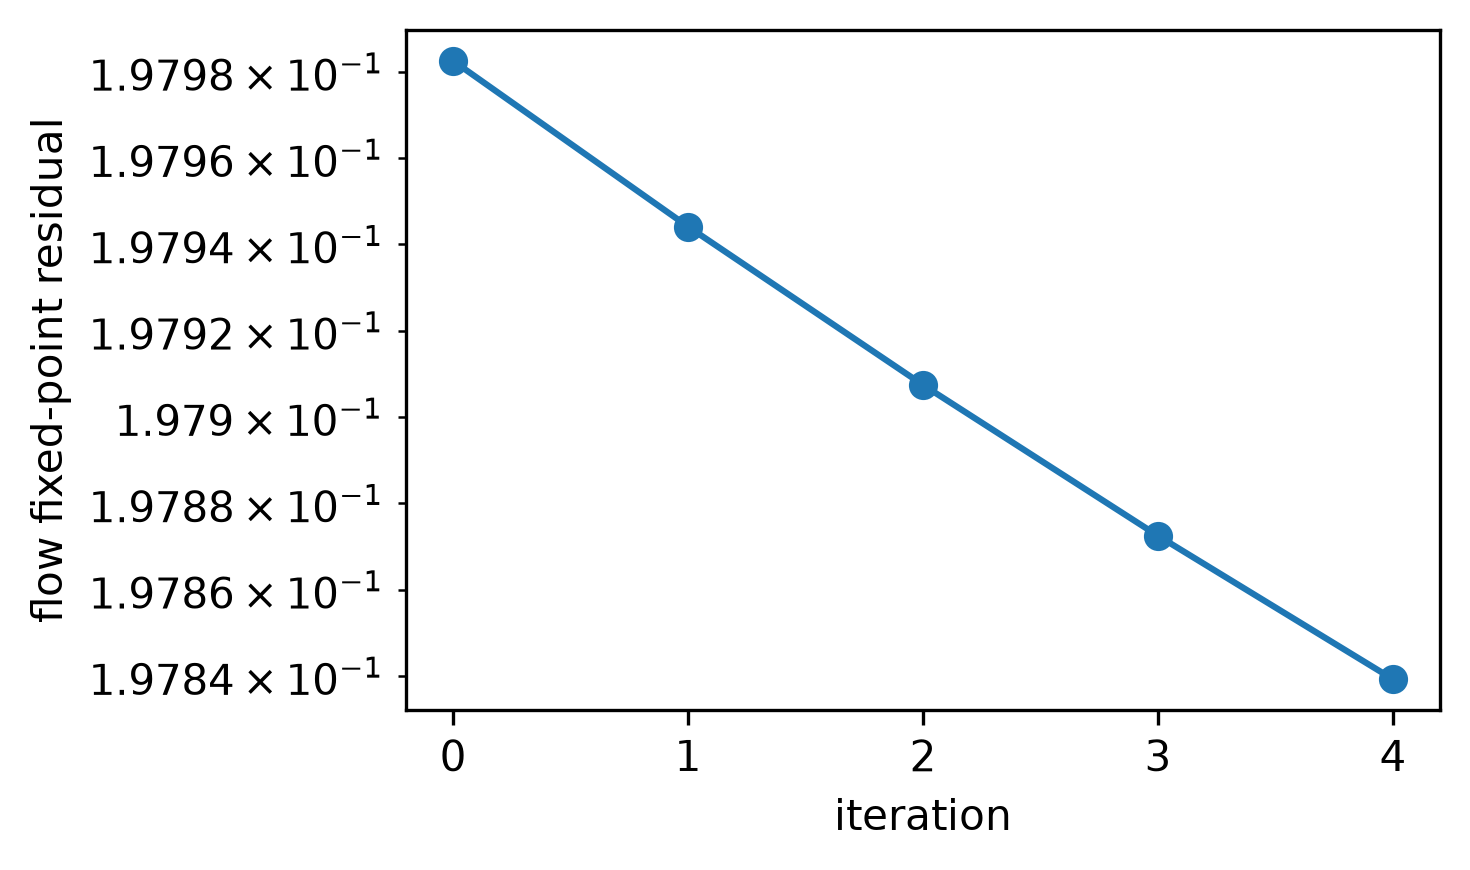

In [7]:
plt.figure(figsize=(5.0, 3.0))
plt.plot(result.solver_result.residuals, marker="o")
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("flow fixed-point residual")
plt.tight_layout()

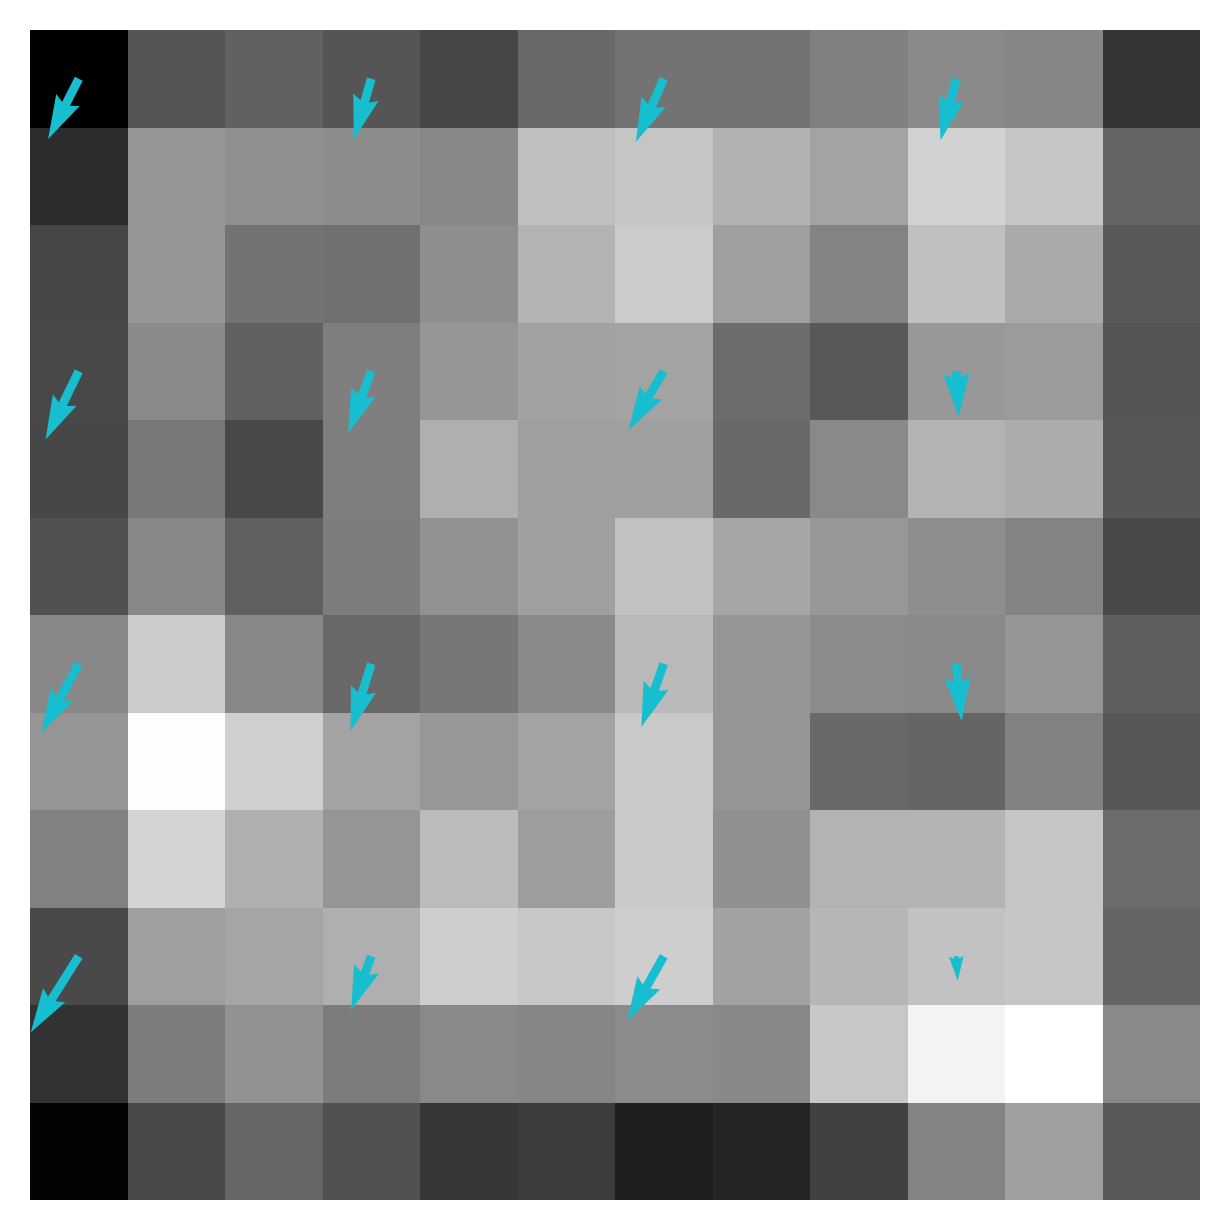

In [8]:
flow = result.flow[0].detach().cpu()
step = 3
y, x_grid = np.mgrid[0:flow.shape[1]:step, 0:flow.shape[2]:step]
u = flow[0, ::step, ::step].numpy()
v = flow[1, ::step, ::step].numpy()
plt.figure(figsize=(4.2, 4.2))
plt.imshow(batch.image1[0, 0].detach().cpu(), cmap="gray")
plt.quiver(x_grid, y, u, v, color="tab:cyan")
plt.axis("off")
plt.tight_layout()

## One Training Step

The model is an ordinary PyTorch module. A supervised validation loss can combine
endpoint error and smoothness.

In [9]:
optim = torch.optim.Adam(model.parameters(), lr=1e-2)
optim.zero_grad()
train_result = model(batch.image1, batch.image2, return_result=True)
loss = silva_endpoint_error(train_result.flow, batch.flow, batch.valid)
loss = loss + 0.01 * silva_flow_smoothness_loss(train_result.flow)
loss.backward()
optim.step()
float(loss.detach().cpu()), model.update.net[-1].weight.grad is not None

(0.8080762028694153, True)

## Citation and Sources

If this package or notebook is used, cite:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.2.2. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770098
```

When the work uses SILVA methodology, also cite:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Additional sources for this notebook:

- TorchDEQ: https://github.com/locuslab/torchdeq
- Deep Equilibrium Optical Flow Estimation: https://arxiv.org/abs/2204.08442
- DEQ-Flow: https://github.com/locuslab/deq-flow
- RAFT: https://arxiv.org/abs/2003.12039
- RAFT repository: https://github.com/princeton-vl/RAFT

The implementation used here is package-native and follows the package solver API.

## From 08 Silva Optical Flow Deq Raft Bridge to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the flow field, optionally coupled to a recurrent hidden state |
| Condition | image features, correlation volumes, context, and initial flow |
| Repeated computation | the tied correlation-conditioned refinement update |
| Required invariants | flow shape, coordinate convention, image resolution, and warping domain |
| Replaceable components | feature/context encoders, correlation, update block, transition, upsampler, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [10]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**endpoint error, warp error, correction loss, and fixed-point residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **image resolution, correlation radius/levels, hidden width, and solver budget**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [11]:
notebook_reproduction_record = {
    "notebook": '08_silva_optical_flow_deq_raft_bridge.ipynb',
    "state": 'the flow field, optionally coupled to a recurrent hidden state',
    "condition": 'image features, correlation volumes, context, and initial flow',
    "transition": 'the tied correlation-conditioned refinement update',
    "invariants": 'flow shape, coordinate convention, image resolution, and warping domain',
    "compact_metric": 'endpoint error, warp error, correction loss, and fixed-point residual',
    "scale_axis": 'image resolution, correlation radius/levels, hidden width, and solver budget',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '08_silva_optical_flow_deq_raft_bridge.ipynb',
 'state': 'the flow field, optionally coupled to a recurrent hidden state',
 'condition': 'image features, correlation volumes, context, and initial flow',
 'transition': 'the tied correlation-conditioned refinement update',
 'invariants': 'flow shape, coordinate convention, image resolution, and warping domain',
 'compact_metric': 'endpoint error, warp error, correction loss, and fixed-point residual',
 'scale_axis': 'image resolution, correlation radius/levels, hidden width, and solver budget'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **refinement feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the flow field, optionally coupled to a recurrent hidden state**, and its repeated map,
**the tied correlation-conditioned refinement update**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [12]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('refinement feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


refinement feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


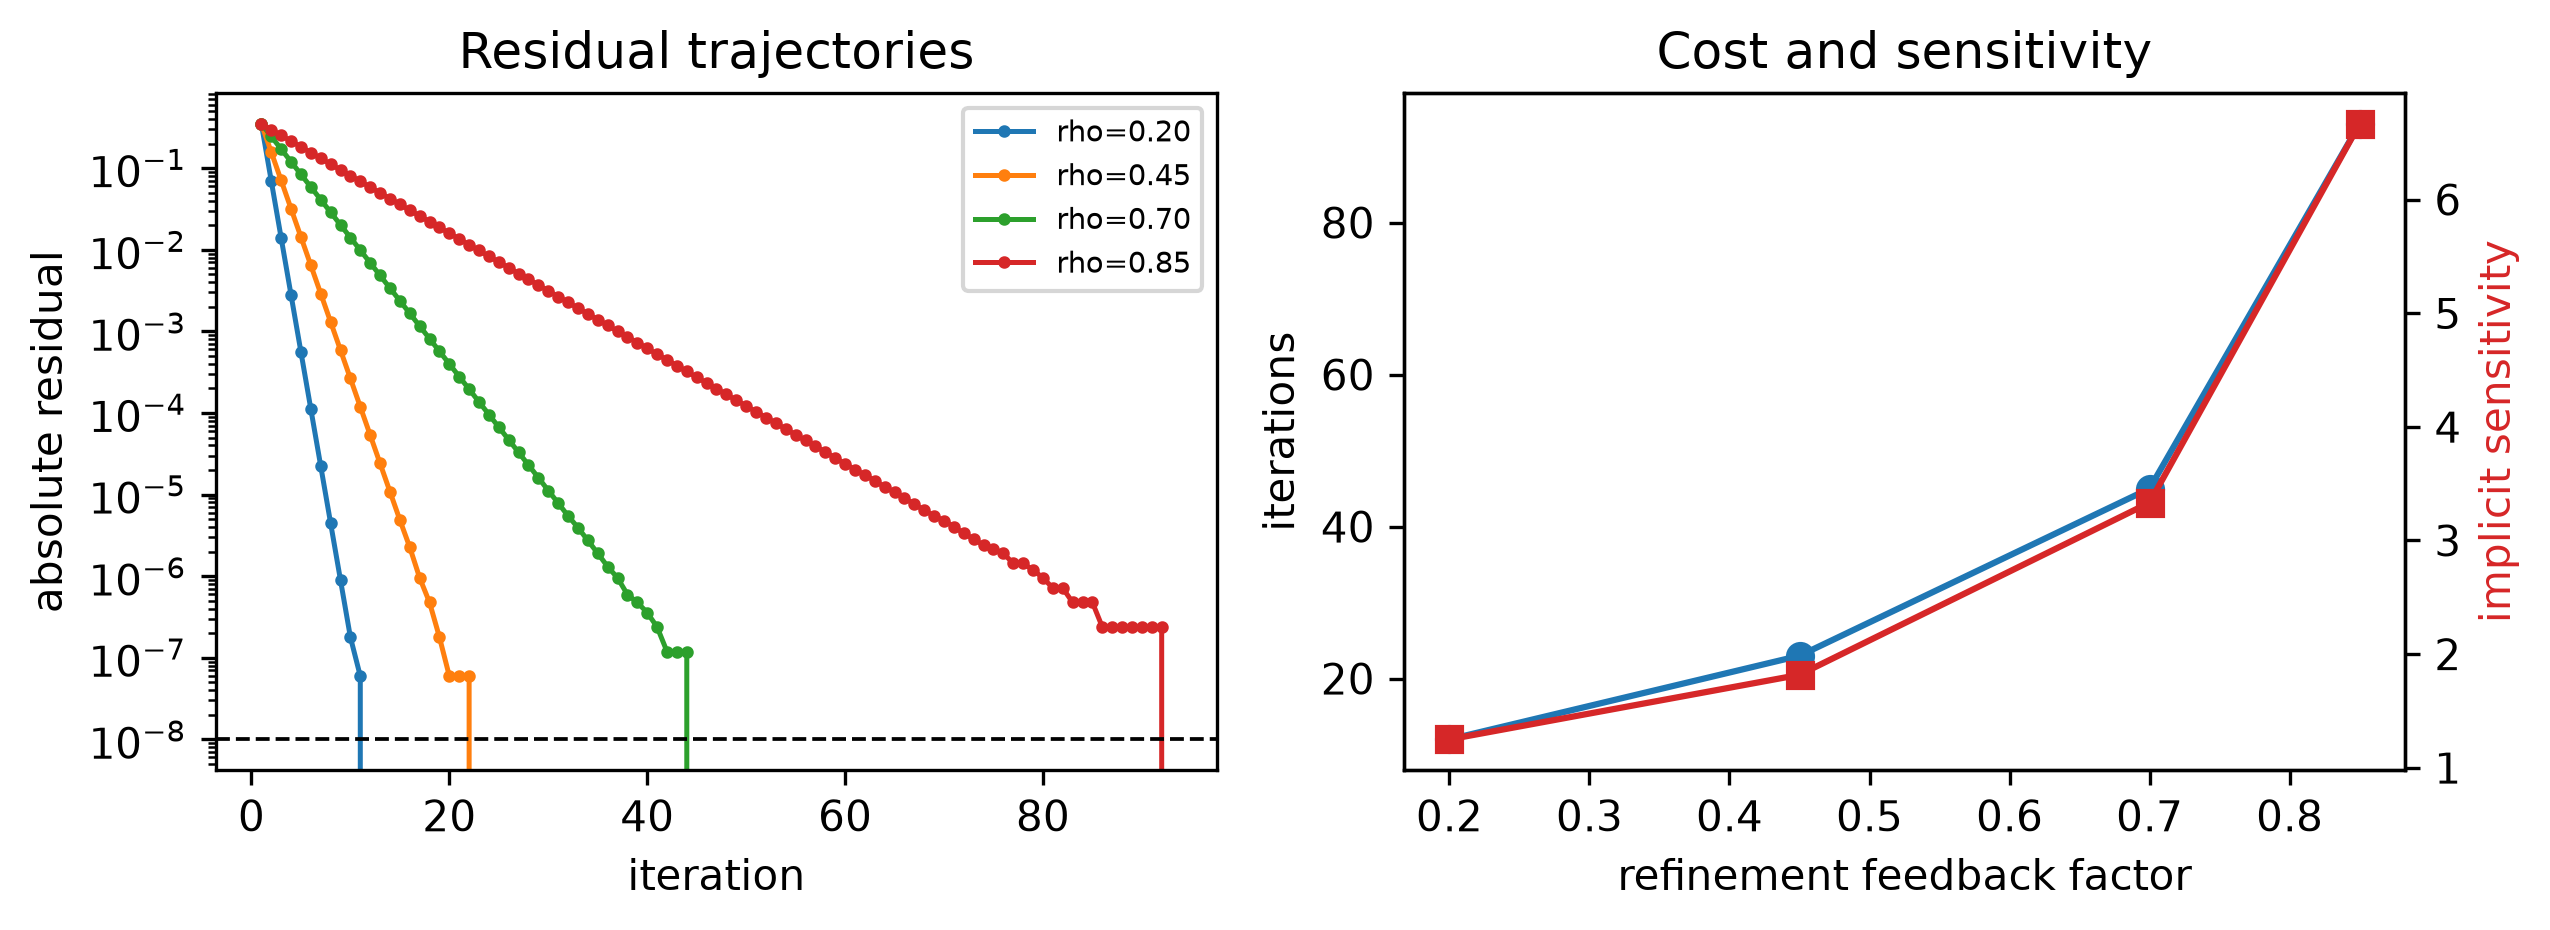

In [13]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('refinement feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the refinement feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | endpoint error, warp error, correction loss, and fixed-point residual |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | flow shape, coordinate convention, image resolution, and warping domain |
| Scale sweep | Change one of image resolution, correlation radius/levels, hidden width, and solver budget at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How is equilibrium optical flow derived? | [DEQ Engine and Optical Flow](https://jseluis.github.io/silva-networks/learn/deq-engine-and-flow/) |
| Where is the compact flow model executed as a script? | [Optical Flow SILVA Example](https://jseluis.github.io/silva-networks/examples/optical-flow-silva/) |
| Which flow modules and losses are public? | [Optical Flow API](https://jseluis.github.io/silva-networks/api/flow/) |
